In [62]:
import pydartdiags.obs_sequence.obs_sequence as obsq
import pydartdiags.matplots.matplots as mp
from pydartdiags.stats import stats
import numpy as np
import matplotlib.pyplot as plt

In [36]:
file_name = "../output/run_gaussian_high/filter1/obs_seq.final.gaussian_high.1"

In [37]:
obs_seq = obsq.ObsSequence(file_name)
obs_type ="RAW_STATE_VARIABLE"
ens_size=10
df = obs_seq.df

In [69]:
stats.diag_stats(obs_seq.df)
df = df[['obs_num','observation','truth','location','prior_sq_err','seconds','days']]
#qc0 = stats.select_used_qcs(obs_seq.df)  # filter only qc=0, qc=2
#qc0 = qc0[qc0["type"] == obs_type]  # filter by type
#qc0
display(df)

mse = df.groupby(['days','seconds'])['prior_sq_err'].mean()

,obs_num,observation,truth,location,prior_sq_err,seconds,days
0,1,-6.733920,-5.583786,0.000000,30.493654,0,0
1,2,0.534778,0.350650,0.333000,0.633122,0,0
2,3,26.628991,30.852533,0.666666,0.000102,0,0
3,4,-8.377877,-5.583786,0.000000,51.352452,500,0
4,5,-1.162413,0.350650,0.333000,0.812705,500,0
...,...,...,...,...,...,...,...
1495,1496,-18.915491,-18.892015,0.333000,0.002202,76200,2
1496,1497,30.932927,35.089195,0.666666,19.994384,76200,2
1497,1498,-16.251033,-16.241931,0.000000,0.024211,76700,2
1498,1499,-19.448530,-18.892015,0.333000,0.236307,76700,2


In [66]:
np.sqrt(mse)

days  seconds
0     0          3.221122
      500        4.703540
      1000       2.606286
      1500       3.558283
      2000       1.575632
                   ...   
2     74700      2.244068
      75200      2.276375
      75700      1.690984
      76200      2.710182
      76700      0.798398
Name: prior_sq_err, Length: 500, dtype: float64

Text(0.5, 1.0, 'help')

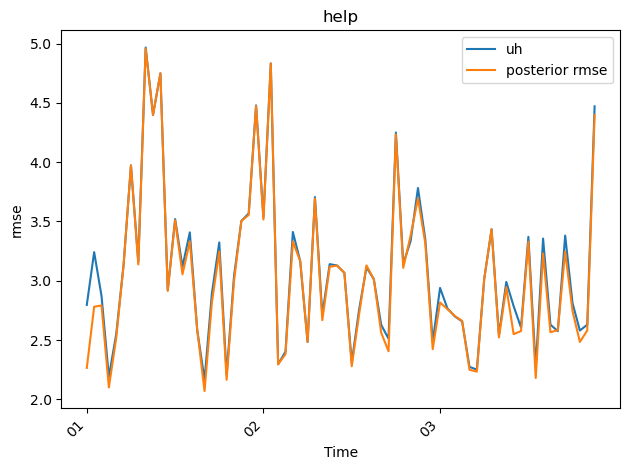

In [22]:
fig = mp.plot_evolution(
    obs_seq=obs_seq,
    type="RAW_STATE_VARIABLE",
    time_bin_width="3600s",  # 1-hour bins
    stat="rmse",
    tick_interval=24,
    time_format="%d", # days
    plot_pvu=False
)
ax = fig.axes[0]
L = ax.get_legend()
L.get_texts()[0].set_text('uh')
ax.set_title("help")

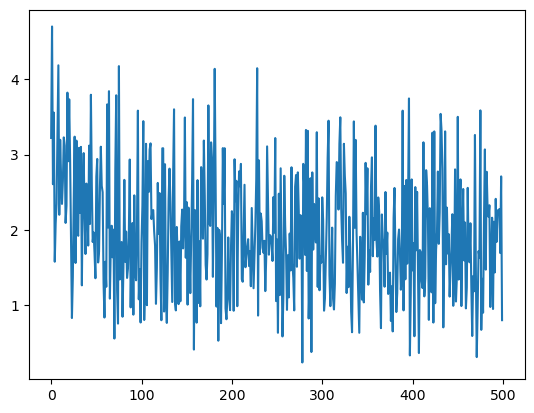

In [67]:
plt.plot(np.sqrt(mse).values)